# Dataset Creation: Conversation Type Classification

Creates a unified dataset of 300 prompts (100 per category) across three conversation types:
- **Math** â€” from GSM8K
- **Riddle** â€” from RiddleSense (+ BrainTeaser if needed)
- **Emotional** â€” from Empathetic Dialogues

Output: `conversation_type_dataset.csv`

In [34]:
# Cell 1: Setup
!pip install -q datasets pandas matplotlib

import re
import json
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TARGET_MIN = 25
TARGET_MAX = 45
SAMPLES_PER_CATEGORY = 100

print("Setup complete.")

Setup complete.


In [35]:
# Cell 2: Load Math Data (GSM8K)
print("Loading GSM8K...")
gsm8k = load_dataset("openai/gsm8k", "main", split="train")
print(f"Raw count: {len(gsm8k)}")

def clean_text(text):
    """General cleaning: strip, collapse whitespace, remove empty."""
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)
    return text

def word_count(text):
    return len(text.split())

def extract_gsm8k_answer(answer_text):
    """Extract the final numerical answer after #### from GSM8K answer field."""
    if "####" in answer_text:
        return answer_text.split("####")[-1].strip()
    return answer_text.strip()

math_prompts = []
for row in gsm8k:
    cleaned = clean_text(row["question"])
    if cleaned:
        math_prompts.append({
            "prompt": cleaned,
            "conversation_type": "math",
            "source": "gsm8k",
            "answer": extract_gsm8k_answer(row["answer"])
        })

df_math = pd.DataFrame(math_prompts)
df_math["word_count"] = df_math["prompt"].apply(word_count)

print(f"After cleaning: {len(df_math)}")
print(f"Word count — mean: {df_math['word_count'].mean():.1f}, std: {df_math['word_count'].std():.1f}, "
      f"min: {df_math['word_count'].min()}, max: {df_math['word_count'].max()}")
print(f"\nSample prompt:\n{df_math['prompt'].iloc[0]}")
print(f"Sample answer: {df_math['answer'].iloc[0]}")

Loading GSM8K...
Raw count: 7473
After cleaning: 7473
Word count — mean: 45.1, std: 17.5, min: 9, max: 183

Sample prompt:
Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
Sample answer: 72


In [36]:
# Cell 3: Load Riddle Data (RiddleSense + BrainTeaser fallback)
# riddle_sense uses a legacy loading script incompatible with datasets v3.x,
# so we download the raw JSONL directly from the source URL.

RIDDLE_SENSE_URL = "https://inklab.usc.edu/RiddleSense/riddlesense_dataset/rs_train.jsonl"

print("Loading RiddleSense (downloading JSONL from source)...")
response = urllib.request.urlopen(RIDDLE_SENSE_URL)
raw_data = response.read().decode("utf-8")

data = []
for line in raw_data.strip().split("\n"):
    if line.strip():
        data.append(json.loads(line))

print(f"Loaded {len(data)} entries")
print(f"Sample entry keys: {list(data[0].keys())}")
print(f"Sample entry: {data[0]}")

def extract_riddle_answer(row):
    """Map answerKey to the actual choice text.
    Choices format: [{"label": "A", "text": "throw"}, {"label": "B", "text": "bit"}, ...]
    """
    q = row.get("question", {})
    answer_key = row.get("answerKey", "")
    if isinstance(q, dict):
        choices = q.get("choices", [])
        for choice in choices:
            if choice.get("label") == answer_key:
                return choice.get("text", answer_key)
    return answer_key

riddle_prompts = []
for row in data:
    # Handle nested question format (CommonsenseQA style: question.stem)
    q = row.get("question", "")
    if isinstance(q, dict):
        question = q.get("stem", "")
    else:
        question = str(q)

    cleaned = clean_text(question)
    if cleaned:
        riddle_prompts.append({
            "prompt": cleaned,
            "conversation_type": "riddle",
            "source": "riddle_sense",
            "answer": extract_riddle_answer(row)
        })

df_riddle = pd.DataFrame(riddle_prompts)
df_riddle["word_count"] = df_riddle["prompt"].apply(word_count)

# Check if we have enough in the target window
in_window = df_riddle[(df_riddle["word_count"] >= TARGET_MIN) & (df_riddle["word_count"] <= TARGET_MAX)]
print(f"\nRiddleSense after cleaning: {len(df_riddle)}")
print(f"RiddleSense in target window [{TARGET_MIN}-{TARGET_MAX}]: {len(in_window)}")

if len(in_window) < SAMPLES_PER_CATEGORY:
    print(f"\nInsufficient samples from RiddleSense ({len(in_window)} < {SAMPLES_PER_CATEGORY}). Loading BrainTeaser...")
    brain_teaser = load_dataset("zihaozhou/BrainTeaser", split="train")
    print(f"BrainTeaser raw count: {len(brain_teaser)}")

    bt_cols = brain_teaser.column_names
    print(f"BrainTeaser columns: {bt_cols}")

    q_field = "question" if "question" in bt_cols else bt_cols[0]
    a_field = "answer" if "answer" in bt_cols else ("answerKey" if "answerKey" in bt_cols else None)

    for row in brain_teaser:
        cleaned = clean_text(row[q_field])
        if cleaned:
            riddle_prompts.append({
                "prompt": cleaned,
                "conversation_type": "riddle",
                "source": "brain_teaser",
                "answer": str(row[a_field]) if a_field else ""
            })

    df_riddle = pd.DataFrame(riddle_prompts)
    df_riddle["word_count"] = df_riddle["prompt"].apply(word_count)
    in_window = df_riddle[(df_riddle["word_count"] >= TARGET_MIN) & (df_riddle["word_count"] <= TARGET_MAX)]
    print(f"Combined riddle data in target window: {len(in_window)}")

print(f"\nWord count — mean: {df_riddle['word_count'].mean():.1f}, std: {df_riddle['word_count'].std():.1f}, "
      f"min: {df_riddle['word_count'].min()}, max: {df_riddle['word_count'].max()}")
print(f"\nSample prompt:\n{df_riddle['prompt'].iloc[0]}")
print(f"Sample answer: {df_riddle['answer'].iloc[0]}")

Loading RiddleSense (downloading JSONL from source)...
Loaded 3510 entries
Sample entry keys: ['id', 'question', 'answerKey']
Sample entry: {'id': 'cxzvpoiuzckf-3123', 'question': {'stem': 'A man is incarcerated in prison, and as his punishment he has to carry a one tonne bag of sand backwards and forwards across a field the size of a football pitch.  What is the one thing he can put in it to make it lighter?', 'choices': [{'label': 'A', 'text': 'throw'}, {'label': 'B', 'text': 'bit'}, {'label': 'C', 'text': 'gallon'}, {'label': 'D', 'text': 'mouse'}, {'label': 'E', 'text': 'hole'}]}, 'answerKey': 'E'}

RiddleSense after cleaning: 3510
RiddleSense in target window [25-45]: 735

Word count — mean: 20.1, std: 14.6, min: 5, max: 100

Sample prompt:
A man is incarcerated in prison, and as his punishment he has to carry a one tonne bag of sand backwards and forwards across a field the size of a football pitch. What is the one thing he can put in it to make it lighter?
Sample answer: hole


In [37]:
# Cell 4: Load Emotional Data (Empathetic Dialogues)
# empathetic_dialogues also uses a legacy loading script,
# so we download the raw CSV directly from the source.

import tarfile
import io
import csv

EMP_URL = "https://dl.fbaipublicfiles.com/parlai/empatheticdialogues/empatheticdialogues.tar.gz"

print("Loading Empathetic Dialogues (downloading from source)...")
response = urllib.request.urlopen(EMP_URL)
archive = tarfile.open(fileobj=io.BytesIO(response.read()), mode="r:gz")

# Read train.csv from the archive
train_member = [m for m in archive.getmembers() if "train.csv" in m.name][0]
f = archive.extractfile(train_member)
reader = csv.DictReader(io.TextIOWrapper(f, encoding="utf-8"))
rows = list(reader)
print(f"Raw row count: {len(rows)}")
print(f"Columns: {list(rows[0].keys())}")

def decode_empathetic_tokens(text):
    """Decode special tokens used in empathetic_dialogues dataset."""
    replacements = {
        "_comma_": ",",
        "_apostrophe_": "'",
        "_exclamation_": "!",
        "_question_": "?",
        "_period_": ".",
        "_colon_": ":",
        "_semicolon_": ";",
        "_dash_": "-",
        "_at_": "@",
        "_hash_": "#",
        "_amp_": "&",
        "_percent_": "%",
        "_dollar_": "$",
        "_star_": "*",
        "_caret_": "^",
        "_tilde_": "~",
        "_pipe_": "|",
        "_backslash_": "\\",
        "_slash_": "/",
        "_leftparen_": "(",
        "_rightparen_": ")",
        "_leftbracket_": "[",
        "_rightbracket_": "]",
        "_leftbrace_": "{",
        "_rightbrace_": "}",
        "_lessthan_": "<",
        "_greaterthan_": ">",
        "_equal_": "=",
        "_plus_": "+",
    }
    for token, char in replacements.items():
        text = text.replace(token, char)
    return text

# Filter to first user utterance per conversation (utterance_idx == 1)
# and deduplicate by conv_id
# The 'context' field holds the emotion label (e.g. "afraid", "grateful")
seen_conv_ids = set()
emotional_prompts = []

for row in rows:
    conv_id = row["conv_id"]
    utterance_idx = int(row["utterance_idx"])

    if utterance_idx == 1 and conv_id not in seen_conv_ids:
        seen_conv_ids.add(conv_id)
        text = row["utterance"]
        # Decode special tokens first, then general clean
        text = decode_empathetic_tokens(text)
        cleaned = clean_text(text)
        if cleaned:
            emotional_prompts.append({
                "prompt": cleaned,
                "conversation_type": "emotional",
                "source": "empathetic_dialogues",
                "answer": row.get("context", "").strip()
            })

df_emotional = pd.DataFrame(emotional_prompts)
df_emotional["word_count"] = df_emotional["prompt"].apply(word_count)

print(f"Unique conversations extracted: {len(df_emotional)}")
print(f"Word count — mean: {df_emotional['word_count'].mean():.1f}, std: {df_emotional['word_count'].std():.1f}, "
      f"min: {df_emotional['word_count'].min()}, max: {df_emotional['word_count'].max()}")
print(f"\nSample prompt:\n{df_emotional['prompt'].iloc[0]}")
print(f"Sample answer (emotion label): {df_emotional['answer'].iloc[0]}")
print(f"\nUnique emotion labels: {df_emotional['answer'].nunique()}")
print(df_emotional['answer'].value_counts().head(10))

Loading Empathetic Dialogues (downloading from source)...
Raw row count: 76673
Columns: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags']
Unique conversations extracted: 17802
Word count — mean: 28.9, std: 334.5, min: 1, max: 17637

Sample prompt:
I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people, we felt like the only people in the world.
Sample answer (emotion label): sentimental

Unique emotion labels: 32
answer
surprised    922
excited      684
angry        637
proud        637
annoyed      612
sad          608
afraid       585
grateful     585
lonely       584
terrified    576
Name: count, dtype: int64


In [38]:
# Cell 5: Length Normalization and Sampling
print("=" * 60)
print("LENGTH NORMALIZATION AND SAMPLING")
print("=" * 60)

categories = {
    "math": df_math,
    "riddle": df_riddle,
    "emotional": df_emotional
}

current_min = TARGET_MIN
current_max = TARGET_MAX
window_widened = False

while True:
    filtered = {}
    all_sufficient = True
    
    print(f"\nTrying window [{current_min}-{current_max}] words...")
    
    for name, df in categories.items():
        mask = (df["word_count"] >= current_min) & (df["word_count"] <= current_max)
        filtered[name] = df[mask]
        count = len(filtered[name])
        print(f"  {name}: {count} samples available")
        
        if count < SAMPLES_PER_CATEGORY:
            all_sufficient = False
    
    if all_sufficient:
        break
    else:
        window_widened = True
        # Widen by 5 words on each side
        current_min = max(5, current_min - 5)
        current_max += 5
        print(f"  WARNING: Insufficient samples. Widening window to [{current_min}-{current_max}]...")

if window_widened:
    print(f"\n*** NOTICE: Window was widened from [{TARGET_MIN}-{TARGET_MAX}] to [{current_min}-{current_max}] ***")
else:
    print(f"\nAll categories have >= {SAMPLES_PER_CATEGORY} samples in [{current_min}-{current_max}]. No widening needed.")

# Sample exactly 100 per category
sampled_dfs = []
for name, df in filtered.items():
    sampled = df.sample(n=SAMPLES_PER_CATEGORY, random_state=SEED).reset_index(drop=True)
    sampled_dfs.append(sampled)
    print(f"\n{name.upper()} â€” sampled {len(sampled)} prompts")
    print(f"  Word count â€” mean: {sampled['word_count'].mean():.1f}, std: {sampled['word_count'].std():.1f}")

# Visual inspection
print("\n" + "=" * 60)
print("SAMPLE PROMPTS FROM EACH CATEGORY")
print("=" * 60)
for df in sampled_dfs:
    cat = df["conversation_type"].iloc[0]
    print(f"\n--- {cat.upper()} ---")
    for i in range(3):
        print(f"  [{i+1}] {df['prompt'].iloc[i][:120]}..." if len(df['prompt'].iloc[i]) > 120 else f"  [{i+1}] {df['prompt'].iloc[i]}")

LENGTH NORMALIZATION AND SAMPLING

Trying window [25-45] words...
  math: 3931 samples available
  riddle: 735 samples available
  emotional: 2059 samples available

All categories have >= 100 samples in [25-45]. No widening needed.

MATH â€” sampled 100 prompts
  Word count â€” mean: 35.6, std: 5.6

RIDDLE â€” sampled 100 prompts
  Word count â€” mean: 32.3, std: 5.5

EMOTIONAL â€” sampled 100 prompts
  Word count â€” mean: 30.9, std: 5.3

SAMPLE PROMPTS FROM EACH CATEGORY

--- MATH ---
  [1] Randy had some money. Smith gave him another $200. Randy then gave Sally $1,200 and kept the rest. If Randy has $2000 le...
  [2] Dave bought 3 packs of white T-shirts and 2 packs of blue T-shirts for his basketball team. The white T-shirts come in p...
  [3] Quincy just bought a car using a 5 year loan with no interest. He put $5,000.00 down as a down payment making his monthl...

--- RIDDLE ---
  [1] I was shot by my wife, Than she drowned me for 20 minutes, After that she hung me for 5 minutes

In [39]:
# Cell 6: Combine and Save
print("Combining all categories...")

df_final = pd.concat(sampled_dfs, ignore_index=True)

# Generate id column
ids = []
counters = {}
for _, row in df_final.iterrows():
    cat = row["conversation_type"]
    counters[cat] = counters.get(cat, 0) + 1
    ids.append(f"{cat}_{counters[cat]:03d}")

df_final["id"] = ids

# Reorder columns to match schema (now includes answer)
df_final = df_final[["id", "conversation_type", "prompt", "answer", "source", "word_count"]]

# Save
output_path = "with_answers_25-45.csv"
df_final.to_csv(output_path, index=False)

print(f"Saved to {output_path}")
print(f"Shape: {df_final.shape}")
print(f"\nValue counts by conversation_type:")
print(df_final["conversation_type"].value_counts())
print(f"\nFirst 5 rows:")
df_final.head()

Combining all categories...
Saved to with_answers_25-45.csv
Shape: (300, 6)

Value counts by conversation_type:
conversation_type
math         100
riddle       100
emotional    100
Name: count, dtype: int64

First 5 rows:


,id,conversation_type,prompt,answer,source,word_count
0,math_001,math,Randy had some money. Smith gave him another $...,3000,gsm8k,33
1,math_002,math,Dave bought 3 packs of white T-shirts and 2 pa...,26,gsm8k,42
2,math_003,math,Quincy just bought a car using a 5 year loan w...,20000,gsm8k,33
3,math_004,math,Austin has 10 pairs of dress shoes he needs to...,11,gsm8k,31
4,math_005,math,Anna used four baking trays to bake cupcakes. ...,96,gsm8k,41


VALIDATION
[PASS] Exactly 300 rows
[PASS] Exactly 100 per category
[PASS] No null values
[PASS] All rows have an answer

Expected columns: ['id', 'conversation_type', 'prompt', 'answer', 'source', 'word_count']

WORD COUNT STATISTICS PER CATEGORY
                    mean   std  min  max
conversation_type                       
emotional          30.94  5.31   25   45
math               35.59  5.57   25   45
riddle             32.27  5.54   25   45

SAMPLE ANSWERS PER CATEGORY

--- MATH ---
  Q: Randy had some money. Smith gave him another $200. Randy then gave Sally $1,200 ...
  A: 3000
  Q: Dave bought 3 packs of white T-shirts and 2 packs of blue T-shirts for his baske...
  A: 26
  Q: Quincy just bought a car using a 5 year loan with no interest. He put $5,000.00 ...
  A: 20000

--- RIDDLE ---
  Q: I was shot by my wife, Than she drowned me for 20 minutes, After that she hung m...
  A: my wife is a photographer
  Q: I spend most of my day eating white. When I am quick enough, I get r

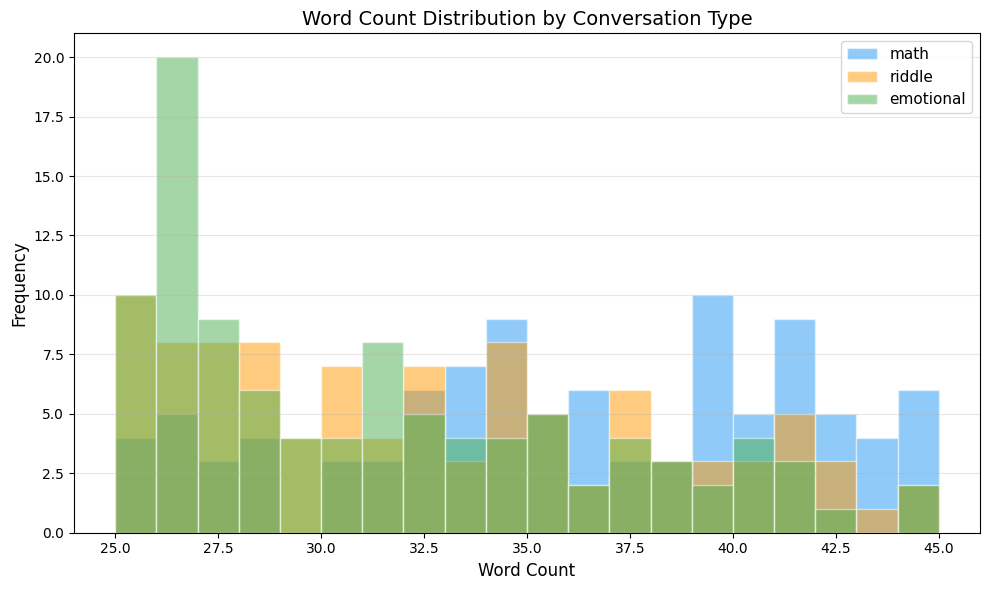


Dataset creation complete!


In [40]:
# Cell 7: Validation and Summary Statistics
print("=" * 60)
print("VALIDATION")
print("=" * 60)

assert len(df_final) == 300, f"Expected 300 rows, got {len(df_final)}"
print("[PASS] Exactly 300 rows")

for cat in ["math", "riddle", "emotional"]:
    count = len(df_final[df_final["conversation_type"] == cat])
    assert count == 100, f"Expected 100 {cat} rows, got {count}"
print("[PASS] Exactly 100 per category")

assert df_final.isnull().sum().sum() == 0, "Found null values!"
print("[PASS] No null values")

assert (df_final["answer"].str.len() > 0).all(), "Found empty answers!"
print("[PASS] All rows have an answer")

print(f"\nExpected columns: {list(df_final.columns)}")

print("\n" + "=" * 60)
print("WORD COUNT STATISTICS PER CATEGORY")
print("=" * 60)
stats = df_final.groupby("conversation_type")["word_count"].agg(["mean", "std", "min", "max"])
print(stats.round(2))

# Show sample answers per category
print("\n" + "=" * 60)
print("SAMPLE ANSWERS PER CATEGORY")
print("=" * 60)
for cat in ["math", "riddle", "emotional"]:
    subset = df_final[df_final["conversation_type"] == cat]
    print(f"\n--- {cat.upper()} ---")
    for i in range(3):
        print(f"  Q: {subset['prompt'].iloc[i][:80]}...")
        print(f"  A: {subset['answer'].iloc[i]}")

# Plot word count distributions
print("\nPlotting word count distributions...")
fig, ax = plt.subplots(figsize=(10, 6))

colors = {"math": "#2196F3", "riddle": "#FF9800", "emotional": "#4CAF50"}
for cat in ["math", "riddle", "emotional"]:
    subset = df_final[df_final["conversation_type"] == cat]["word_count"]
    ax.hist(subset, bins=20, alpha=0.5, label=cat, color=colors[cat], edgecolor="white")

ax.set_xlabel("Word Count", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Word Count Distribution by Conversation Type", fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("word_count_distribution.png", dpi=150)
plt.show()

print("\nDataset creation complete!")